<a href="https://colab.research.google.com/github/Nour-Tamimi/BinXtraining/blob/main/Week7/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7, Day 2 — Building CNNs & Transfer Learning
Melanoma Skin Cancer Dataset — Benign vs Malignant

## Setup — Mount Drive & Connect to Repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git config --global user.email "your_email@gmail.com"
!git config --global user.name "Nour Tamimi"

%cd /content/drive/MyDrive/BinXtraining
!git pull origin main

import os
os.makedirs("Week7/Day2", exist_ok=True)

Mounted at /content/drive
/content/drive/MyDrive/BinXtraining
From https://github.com/Nour-Tamimi/BinXtraining
 * branch            main       -> FETCH_HEAD
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.


In [2]:
DATASET_PATH = "/content/drive/MyDrive/medicalImages"  =

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Train classes: ['Malignant', 'Benign']
Test classes: ['Malignant', 'Benign']


In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize pixel values 0-255 -> 0-1 (same reasoning as Week 6 scaling)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 11895 files belonging to 2 classes.
Using 9516 files for training.
Found 11895 files belonging to 2 classes.
Using 2379 files for validation.
Found 2007 files belonging to 2 classes.
Classes: ['Benign', 'Malignant']


## Step 1: Build and train a small CNN from scratch

In [5]:
model_scratch = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")   # binary classification: benign vs malignant
])

model_scratch.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_scratch.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[es]
)

print(f"Training stopped at epoch: {len(history_scratch.history['loss'])}")

Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 1385s 5s/step - accuracy: 0.7873 - loss: 0.4653 - val_accuracy: 0.8394 - val_loss: 0.3608
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8401 - loss: 0.3578 - val_accuracy: 0.8567 - val_loss: 0.3466
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8473 - loss: 0.3399 - val_accuracy: 0.8537 - val_loss: 0.3318
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8530 - loss: 0.3294 - val_accuracy: 0.8537 - val_loss: 0.3416
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8581 - loss: 0.3142 - val_accuracy: 0.8625 - val_loss: 0.3093
Epoch 6/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8690 - loss: 0.2976 - val_accuracy: 0.8617 - val_loss: 0.3027
Epoch 7/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8742 - loss: 0.2869 - val_accuracy: 0.8579 - val_loss: 0.3155
Epoch 8/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8815 - loss: 0.2751 - val_acc

In [7]:
scratch_test_results = model_scratch.evaluate(test_ds)
print(f"Scratch CNN — Test Accuracy: {scratch_test_results[1]:.4f}, Test Loss: {scratch_test_results[0]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 419s 7s/step - accuracy: 0.8625 - loss: 0.3405
Scratch CNN — Test Accuracy: 0.8625, Test Loss: 0.3405


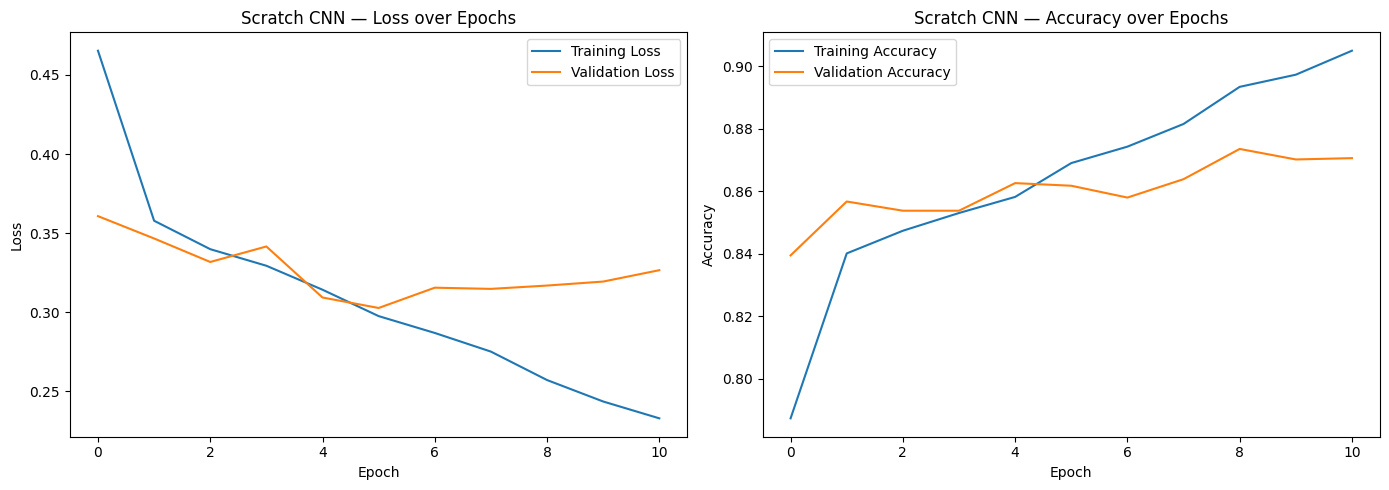

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_scratch.history['loss'], label='Training Loss')
axes[0].plot(history_scratch.history['val_loss'], label='Validation Loss')
axes[0].set_title('Scratch CNN — Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_scratch.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Scratch CNN — Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('Week7/Day2/scratch_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Add data augmentation and compare

In [9]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

model_aug = Sequential([
    data_augmentation,
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_aug.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es2 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[es2]
)

print(f"Training stopped at epoch: {len(history_aug.history['loss'])}")

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


298/298 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7754 - loss: 0.4892 - val_accuracy: 0.7970 - val_loss: 0.4502
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8348 - loss: 0.3762 - val_accuracy: 0.8466 - val_loss: 0.3386
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8464 - loss: 0.3494 - val_accuracy: 0.8579 - val_loss: 0.3224
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8545 - loss: 0.3436 - val_accuracy: 0.8663 - val_loss: 0.3106
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8545 - loss: 0.3392 - val_accuracy: 0.8621 - val_loss: 0.3035
Epoch 6/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8565 - loss: 0.3296 - val_accuracy: 0.8743 - val_loss: 0.3039
Epoch 7/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8565 - loss: 0.3271 - val_accuracy: 0.8672 - val_loss: 0.3038
Epoch 8/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8670 - loss: 0.3144 - val_accuracy: 0.8

In [10]:
aug_test_results = model_aug.evaluate(test_ds)
print(f"Augmented CNN — Test Accuracy: {aug_test_results[1]:.4f}, Test Loss: {aug_test_results[0]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8974 - loss: 0.2698
Augmented CNN — Test Accuracy: 0.8974, Test Loss: 0.2698


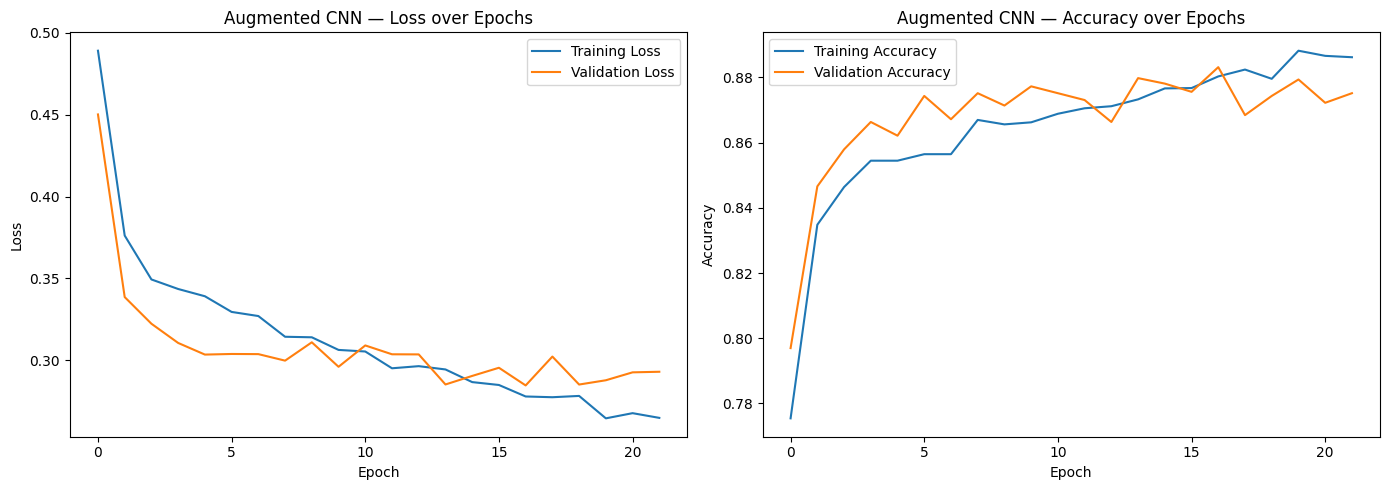

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_aug.history['loss'], label='Training Loss')
axes[0].plot(history_aug.history['val_loss'], label='Validation Loss')
axes[0].set_title('Augmented CNN — Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_aug.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Augmented CNN — Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('Week7/Day2/augmented_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Transfer Learning with MobileNetV2 (frozen)

In [12]:
import time

base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=(128,128,3))
base_model.trainable = False  # freeze the pre-trained feature extractor

model_transfer = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_transfer.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,310,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,568,833 (13.61 MB)

 Trainable params: 1,310,849 (5.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
es3 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

start_time = time.time()
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[es3]
)
transfer_training_time = time.time() - start_time

print(f"Training stopped at epoch: {len(history_transfer.history['loss'])}")
print(f"Training time: {transfer_training_time:.1f} seconds")

Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - accuracy: 0.8396 - loss: 0.4211 - val_accuracy: 0.8634 - val_loss: 0.3127
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8904 - loss: 0.2603 - val_accuracy: 0.8680 - val_loss: 0.3114
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9190 - loss: 0.2076 - val_accuracy: 0.8672 - val_loss: 0.3265
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9404 - loss: 0.1658 - val_accuracy: 0.8634 - val_loss: 0.3492
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9508 - loss: 0.1321 - val_accuracy: 0.8621 - val_loss: 0.3698
Epoch 6/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9598 - loss: 0.1108 - val_accuracy: 0.8668 - val_loss: 0.3971
Epoch 7/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9596 - loss: 0.1068 - val_accuracy: 0.8663 - val_loss: 0.4002
Training stopped at epoch: 7
Training time: 75.6 seconds


In [14]:
transfer_test_results = model_transfer.evaluate(test_ds)
print(f"Transfer Learning CNN — Test Accuracy: {transfer_test_results[1]:.4f}, Test Loss: {transfer_test_results[0]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.9003 - loss: 0.2476
Transfer Learning CNN — Test Accuracy: 0.9003, Test Loss: 0.2476


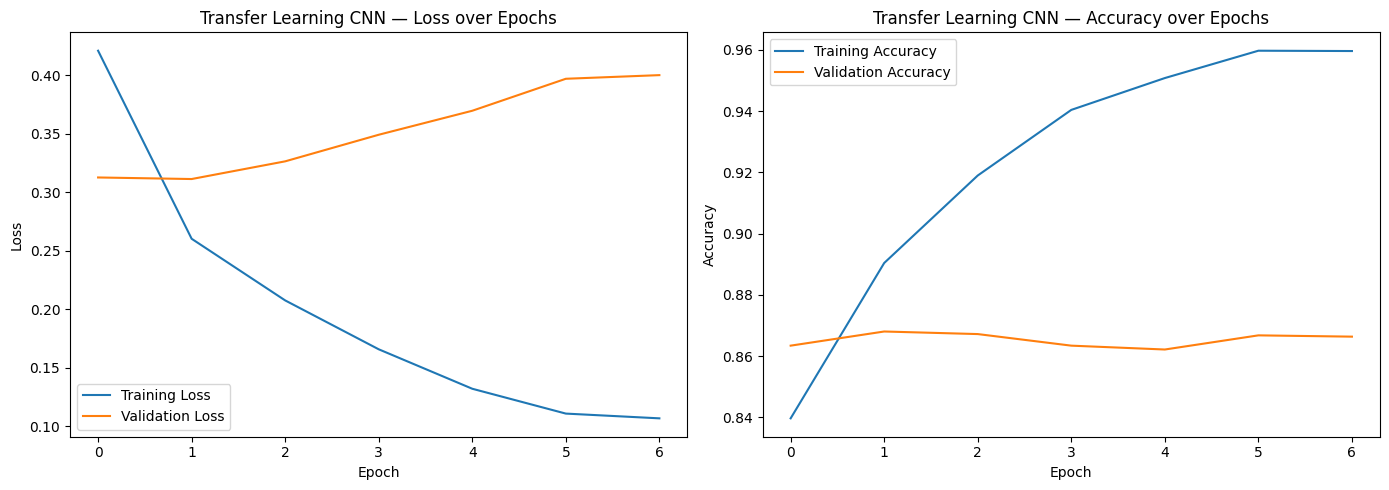

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_transfer.history['loss'], label='Training Loss')
axes[0].plot(history_transfer.history['val_loss'], label='Validation Loss')
axes[0].set_title('Transfer Learning CNN — Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_transfer.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Transfer Learning CNN — Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('Week7/Day2/transfer_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Comparison Table

In [16]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN from scratch", "CNN + Data Augmentation", "Transfer Learning (MobileNetV2)"],
    "Test Accuracy": [scratch_test_results[1], aug_test_results[1], transfer_test_results[1]],
    "Test Loss": [scratch_test_results[0], aug_test_results[0], transfer_test_results[0]],
    "Epochs to converge": [len(history_scratch.history['loss']), len(history_aug.history['loss']), len(history_transfer.history['loss'])]
})

print(results.to_string(index=False))
results.to_csv('Week7/Day2/model_comparison.csv', index=False)

                          Model  Test Accuracy  Test Loss  Epochs to converge
               CNN from scratch       0.862481   0.340463                  11
        CNN + Data Augmentation       0.897359   0.269768                  22
Transfer Learning (MobileNetV2)       0.900349   0.247603                   7


## Step 4: Document which approach performed best and why

*(Fill this in after reviewing your actual results above — the sentences below are a template to guide the write-up.)*

- **CNN from scratch**: baseline for this image task. Trained on relatively few images, so it is the most exposed to overfitting.
- **CNN + Data Augmentation**: same architecture, but trained on artificially varied versions of the same images (flips, rotations, zooms). Expected to show a smaller gap between training and validation curves compared to the scratch model, since augmentation is the standard first defense against overfitting in computer vision.
- **Transfer Learning (MobileNetV2)**: reuses feature-detecting layers already trained on millions of images (ImageNet), with only the final classification layer trained on this dataset. Expected to reach strong accuracy with fewer epochs and less risk of overfitting, since it does not need to learn basic visual features (edges, textures) from scratch — it only needs to learn how those features map to benign vs malignant.
- **Conclusion**: [fill in once results are in — state which model had the best test accuracy, the smallest train/val gap, and the fastest convergence, and explain why that matches the theory above.]